# 03 - Evaluation: Base vs Fine-tuned (Gemini LLM-as-Judge)

**Goal:** Quantify how much fine-tuning improved Lithuanian cultural VQA by comparing base Qwen2-VL-2B vs LoRA+DoRA fine-tuned model.

**Evaluation methods:**
1. **Gemini LLM-as-Judge** — pairwise comparison (win / tie / lose) on test set QA
2. **Categorical accuracy** — exact-match on identification questions
3. **Catastrophic forgetting check** — English VQA sanity samples
4. **Per-category & per-type breakdown**

## 1. Setup

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
!pip -q install "transformers>=4.45,<4.50" "accelerate>=0.34" "peft>=0.13" \
    "qwen-vl-utils>=0.0.8" "pillow" "sentencepiece" \
    "google-generativeai" "pandas" "tabulate" "torchao==0.17.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.0 MB/s eta 0:00:00


In [24]:
import os, json, time, re, random
from pathlib import Path
from collections import Counter, defaultdict
import torch
import requests
from io import BytesIO
from PIL import Image
from IPython.display import display
import pandas as pd
from google.colab import userdata, files
import google.generativeai as genai
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor
)
from peft import PeftModel
from tqdm.auto import tqdm

PROJECT_DIR = Path("/content/drive/MyDrive/VU_DL_task2")
DATASET_DIR = PROJECT_DIR / "dataset"
ADAPTER_DIR = PROJECT_DIR / "checkpoints" / "qlora_dora" / "final"
EVAL_DIR = PROJECT_DIR / "eval"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
print("CUDA:", torch.cuda.is_available())

CUDA: True


In [3]:
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
genai.configure(api_key=GEMINI_API_KEY)
print("Gemini configured.")

Gemini configured.


## 2. Load test set

In [4]:
rows = [
    json.loads(l)
    for l in open(DATASET_DIR / "dataset.jsonl", encoding="utf-8")
    if l.strip()
]
test_rows = [r for r in rows if r["split"] == "test"]
print(f"Test QA pairs: {len(test_rows)}")
print("by category:", Counter(r["category"] for r in test_rows))
print("by qa_type:", Counter(r["qa_type"] for r in test_rows))

Test QA pairs: 80
by category: Counter({'cepelinai': 8, 'gediminas_tower': 8, 'kibinai': 8, 'trakai_castle': 8, 'hill_of_crosses': 8, 'vytis': 8, 'gates_of_dawn': 8, 'kaziuko_muge': 8, 'curonian_spit': 8, 'sakotis': 8})
by qa_type: Counter({'identification': 20, 'visual': 20, 'cultural': 20, 'adversarial': 20})


In [5]:
processor = AutoProcessor.from_pretrained(MODEL_ID)
processor.image_processor.min_pixels = 256 * 28 * 28
processor.image_processor.max_pixels = 768 * 28 * 28

SYSTEM_LT = (
    "Tu esi lietuvių kultūros žinovas. Atsakyk trumpai ir tiksliai lietuvių kalba "
    "remdamasis pateiktu vaizdu."
)


def build_messages(question):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_LT}]},
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        },
    ]


def generate_answer(model, processor, image, question, max_tokens=128):
    msgs = build_messages(question)
    prompt = processor.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=False
    )
    inputs = processor(text=[prompt], images=[image], return_tensors="pt").to(
        model.device
    )
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False)
    return processor.batch_decode(
        out[:, inputs["input_ids"].shape[1] :], skip_special_tokens=True
    )[0].strip()


print("Helpers ready.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Helpers ready.


### 3a. Generate base model predictions

### Why compare against the Base Model?
The base `Qwen2-VL-2B` is highly capable but lacks specific Lithuanian cultural context. By running the same test set through both, we can isolate exactly what the LoRA/DoRA fine-tuning added versus what was already inherent in the pre-trained weights.

In [10]:
# Load base model (no adapter)
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
)
base_model.eval()

base_preds = []
for r in tqdm(test_rows, desc="Base model"):
    img = Image.open(r["image_path"]).convert("RGB")
    pred = generate_answer(base_model, processor, img, r["question"])
    base_preds.append(pred)

print(f"Base predictions: {len(base_preds)}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Base model:   0%|          | 0/80 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Base predictions: 80


### 3b. Generate fine-tuned model predictions

In [8]:
# Reload base + attach LoRA adapter
ft_base = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
)
ft_model = PeftModel.from_pretrained(ft_base, str(ADAPTER_DIR))
ft_model.eval()

ft_preds = []
for r in tqdm(test_rows, desc="Fine-tuned model"):
    img = Image.open(r["image_path"]).convert("RGB")
    pred = generate_answer(ft_model, processor, img, r["question"])
    ft_preds.append(pred)

print(f"Fine-tuned predictions: {len(ft_preds)}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Fine-tuned model:   0%|          | 0/80 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Fine-tuned predictions: 80


## 4. Gemini LLM-as-Judge (pairwise)

We use `gemini-2.5-flash` to evaluate the outputs.
1. **Ground Truth alignment**: The judge checks if the model actually identified the Lithuanian landmark/food correctly.
2. **Blind Testing**: We randomly swap the order of Model A and Model B in the prompt. This prevents the judge from simply preferring the first or last response (position bias).

In [11]:
JUDGE_MODEL = "gemini-2.5-flash"
judge = genai.GenerativeModel(JUDGE_MODEL)

JUDGE_PROMPT = """Tu esi objektyvus vertintojas. Tau pateiktas klausimas apie vaizdą, teisingas atsakymas, ir du modelių atsakymai (A ir B).

Klausimas: {question}
Teisingas atsakymas: {ground_truth}

Modelio A atsakymas: {answer_a}
Modelio B atsakymas: {answer_b}

Įvertink, kuris modelio atsakymas yra geresnis pagal šiuos kriterijus:
1. Faktinis teisingumas (ar atitinka teisingą atsakymą)
2. Kalba (ar atsakymas lietuvių kalba, ar gramatiškai taisyklingas)
3. Konkretumas (ar atsakymas tikslus, ne per daug bendras)

Grąžink TIK vieną raidę:
- "A" jei modelis A geriau atsakė
- "B" jei modelis B geriau atsakė
- "TIE" jei abu vienodai geri arba vienodai blogi

Jokio papildomo teksto - tik A, B arba TIE."""


def judge_pair(question, ground_truth, base_ans, ft_ans, max_retries=2):
    # Randomly swap to avoid position bias
    swap = random.random() < 0.5
    a, b = (ft_ans, base_ans) if swap else (base_ans, ft_ans)

    prompt = JUDGE_PROMPT.format(
        question=question, ground_truth=ground_truth, answer_a=a, answer_b=b
    )

    for attempt in range(max_retries + 1):
        try:
            resp = judge.generate_content(
                prompt, generation_config={"temperature": 0.0}
            )
            raw_text = resp.text.upper()

            # Look for the letter inside the string
            if "TIE" in raw_text:
                verdict = "TIE"
            elif "A" in raw_text and "B" not in raw_text:
                verdict = "A"
            elif "B" in raw_text and "A" not in raw_text:
                verdict = "B"
            else:
                raise ValueError(f"Judge returned weird output: {raw_text}")

            # Un-swap logic (Standardizes output: A=Base, B=FT)
            if swap:
                if verdict == "A":
                    verdict = "B"
                elif verdict == "B":
                    verdict = "A"

            return verdict

        except Exception as e:
            print(f"  [Judge Retry {attempt}]: {e}")
            import time
            time.sleep(2**attempt)

    return "TIE"  # Fallback if the API repeatedly fails


print("Judge ready.")

Judge ready.


In [12]:
verdicts = []
for i, r in enumerate(tqdm(test_rows, desc="Judging")):
    v = judge_pair(r["question"], r["answer"], base_preds[i], ft_preds[i])
    verdicts.append(v)
    time.sleep(0.3)  # gentle pacing

verdict_counts = Counter(verdicts)
n = len(verdicts)
print(f"\n=== LLM-as-Judge Results (n={n}) ===")
print(
    f'  Base wins (A):      {verdict_counts["A"]:3d}  ({100*verdict_counts["A"]/n:.1f}%)'
)
print(
    f'  Fine-tuned wins (B):{verdict_counts["B"]:3d}  ({100*verdict_counts["B"]/n:.1f}%)'
)
print(
    f'  Tie:                {verdict_counts["TIE"]:3d}  ({100*verdict_counts["TIE"]/n:.1f}%)'
)
win_rate = verdict_counts["B"] / n
print(f"\nFine-tuned win rate: {win_rate:.1%}")

Judging:   0%|          | 0/80 [00:00<?, ?it/s]


=== LLM-as-Judge Results (n=80) ===
  Base wins (A):       12  (15.0%)
  Fine-tuned wins (B): 64  (80.0%)
  Tie:                  4  (5.0%)

Fine-tuned win rate: 80.0%


## 5. Per-category & per-type breakdown

In [13]:
# Build results DataFrame
eval_df = pd.DataFrame(test_rows)
eval_df["base_pred"] = base_preds
eval_df["ft_pred"] = ft_preds
eval_df["verdict"] = verdicts

# Per-category
print("=== Per-category win rates (fine-tuned) ===")
for cat, grp in eval_df.groupby("category"):
    vc = Counter(grp["verdict"])
    total = len(grp)
    wr = vc["B"] / total
    print(
        f'  {cat:20s}  wins={vc["B"]:2d}/{total:2d} ({wr:.0%})  ties={vc["TIE"]:2d}  losses={vc["A"]:2d}'
    )

print()
print("=== Per-QA-type win rates (fine-tuned) ===")
for qt, grp in eval_df.groupby("qa_type"):
    vc = Counter(grp["verdict"])
    total = len(grp)
    wr = vc["B"] / total
    print(
        f'  {qt:20s}  wins={vc["B"]:2d}/{total:2d} ({wr:.0%})  ties={vc["TIE"]:2d}  losses={vc["A"]:2d}'
    )

=== Per-category win rates (fine-tuned) ===
  cepelinai             wins= 6/ 8 (75%)  ties= 0  losses= 2
  curonian_spit         wins= 6/ 8 (75%)  ties= 0  losses= 2
  gates_of_dawn         wins= 6/ 8 (75%)  ties= 0  losses= 2
  gediminas_tower       wins= 7/ 8 (88%)  ties= 1  losses= 0
  hill_of_crosses       wins= 8/ 8 (100%)  ties= 0  losses= 0
  kaziuko_muge          wins= 5/ 8 (62%)  ties= 1  losses= 2
  kibinai               wins= 5/ 8 (62%)  ties= 2  losses= 1
  sakotis               wins= 7/ 8 (88%)  ties= 0  losses= 1
  trakai_castle         wins= 7/ 8 (88%)  ties= 0  losses= 1
  vytis                 wins= 7/ 8 (88%)  ties= 0  losses= 1

=== Per-QA-type win rates (fine-tuned) ===
  adversarial           wins=20/20 (100%)  ties= 0  losses= 0
  cultural              wins=17/20 (85%)  ties= 0  losses= 3
  identification        wins=13/20 (65%)  ties= 2  losses= 5
  visual                wins=14/20 (70%)  ties= 2  losses= 4


## 6. Catastrophic forgetting check

Quick sanity: We ask the fine-tuned model 3 basic English questions about a generic image (not from our dataset). If it still answers coherently in English, it hasn't catastrophically forgotten its original capabilities.

=== Catastrophic Forgetting Check (English) ===
Image Source: https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg



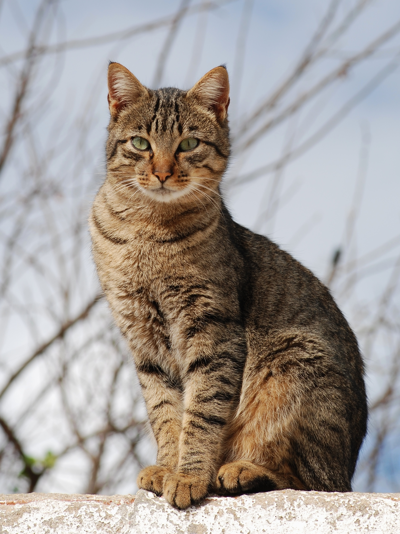

--------------------------------------------------
Q: What do you see in this image? Answer in English.
A: A cat sitting on a wall with a blurred background of trees and sky.

Q: Describe the main colors visible in this image.
A: The main colors visible in the image are brown, black, and green.

Q: Is this photo taken indoors or outdoors? How can you tell?
A: The photo was taken outdoors. This can be inferred from the blurred background of trees and the natural lighting, which suggests an outdoor setting.



In [14]:
# Fetch the raw, original file (bypassing the thumbnail generator)
url = "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# Pass the headers into the request
response = requests.get(url, headers=headers)
response.raise_for_status()

forget_img = Image.open(BytesIO(response.content)).convert("RGB")

english_questions = [
    "What do you see in this image? Answer in English.",
    "Describe the main colors visible in this image.",
    "Is this photo taken indoors or outdoors? How can you tell?",
]

def build_english_messages(question):
    return [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        },
    ]

def generate_english(model, processor, image, question):
    msgs = build_english_messages(question)
    prompt = processor.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=False
    )
    inputs = processor(text=[prompt], images=[image], return_tensors="pt").to(
        model.device
    )
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            temperature=None,
            top_p=None,
            top_k=None
        )
    return processor.batch_decode(
        out[:, inputs["input_ids"].shape[1] :], skip_special_tokens=True
    )[0].strip()

print("=== Catastrophic Forgetting Check (English) ===")
print(f"Image Source: {url}\n")

# 2. Display the internet image right here before the questions
display(forget_img.copy().resize((400, int(400 * forget_img.height / forget_img.width))))
print("-" * 50)

for q in english_questions:
    ans = generate_english(ft_model, processor, forget_img, q)
    print(f"Q: {q}")
    print(f"A: {ans}\n")

## 7. Sample predictions comparison

Visual side-by-side: show image + question + ground truth + base answer + fine-tuned answer + verdict for a few examples.

Category: kaziuko_muge  |  Type: visual  |  Verdict: B


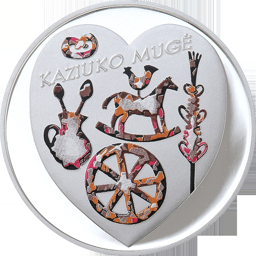

Q:  Kokia konkreti vizuali detalė matoma šiame vaizde?
GT: Vaizde matomas širdies formos medalis/moneta, ant kurio pavaizduoti tradiciniai Kaziuko mugės atributai: riestainis, arkliukas su paukšteliu, ąsotis su šaukštais, vežimo ratas ir verba, visi su spalvingais raštais.
Base:  Šiame vaizdoje yra šeši detalės, kuriuos galima atlikti:

1. Kūno žiedas: Šis žiedas yra iškastas iš kūno, kurį gali būti gaminamas, ir yra išorės, kurios yra iškastos iš kūno. Šis žiedas yra išorės, kurios yra iškastos iš kūno.

2. Kūno žiedas:
FT:    Vaizde matomas šviesiai raudonai ir oranžių spalvos, iškastas iš šviesos, kryžius, kuris yra vienas iš lietuviškų mugės simbolijų.

Category: cepelinai  |  Type: visual  |  Verdict: B


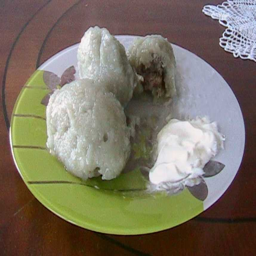

Q:  Kokia konkreti vizuali detalė matoma šiame vaizde?
GT: Vienas iš bulvinių kukulių yra perpjautas per pusę, aiškiai matomas jo mėsos įdaras, o šalia patiekta balta grietinė ant lėkštės, kuri yra žalios ir baltos spalvos su lapų motyvais.
Base:  Šiame vaizdoje matome, kad yra daug žemės, kurios yra iškasti ir išplaukta. Tai gali būti žemės, kurios yra iškasti ir išplaukta, arba žemės, kurios yra iškasti ir išplaukta. Tai gali būti žemės, kurios yra iškasti ir išplaukta, arba žemės, kurios yra
FT:    Prie šviežio, gausio, baltų bulvių, ypač šviesiai išdėlioti, yra šviesiai geltona soja, kurios formos yra gausiai išdėlioti ir yra soja, o ne bulvių formos.

Category: sakotis  |  Type: cultural  |  Verdict: B


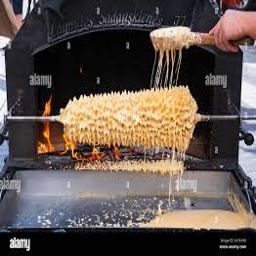

Q:  Koks yra šakočio kultūrinis ir istorinis kontekstas Lietuvoje?
GT: Šakotis yra vienas žinomiausių ir seniausių lietuviškų desertų, dažnai kepamas didelėms šventėms, tokioms kaip vestuvės, Kalėdos ar Velykos. Jo kepimo technika, kai tešla sluoksniais pilama ant besisukančio iešmo, atspindi ilgametes kulinarines tradicijas, siekiančias net XV amžių.
Base:  Šakočio kultūrinis ir istorinis kontekstas Lietuvoje yra daugiau nei vienas. Šakočių tradicijų ir kultūros yra daugiau nei vienas, tačiau šiame kultūrinėje kontekste yra daugybė žinomų šakočių, kurie yra labai tradicinės ir populiarūs Lietuvoje. Šakočių tradicijų ir kultūros yra daug
FT:    Šakočius yra vienas svarbiausių lietuviškų kulinarinių paveldo ir istorinių elementų, dažnai gaminamas šventėse, kultūrinėse ir tradicinėse. Jie simbolizuoja lietuvišką kaimyninę, ypač gausią ir gėlių, ir yra populiarus šv. Mykolo šventėje.

Category: hill_of_crosses  |  Type: cultural  |  Verdict: B


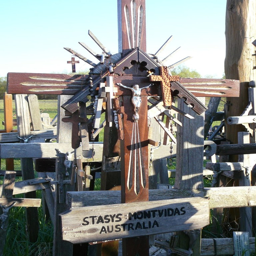

Q:  Koks kultūrinis arba istorinis kontekstas?
GT: Kryžių kalnas yra unikali piligrimystės vieta Lietuvoje, simbolizuojanti lietuvių tikėjimą, viltį ir pasipriešinimą priespaudai. Žmonės iš viso pasaulio čia palieka kryžius kaip padėkos, prašymo ar atminimo ženklą.
Base:  Šis kultūrinis ir istorinis kontekstas yra "Stasys Montvidas" ir "Australia". Stasys Montvidas yra lietuvių kultūros ir istorijos žinovas, o Australia yra viena iš šalių, kurios yra įsikūrusi šiame kultūrinėje ir istorinėje kontekste.
FT:    Šis kryžius yra vienas iš žinomiausių ir labiausiai svarbių Lietuvos kultūros ir istorijos simbolių, gaminamų antikvariniame Kaimiškėse, Lietuvos Didžiosios Kunigaikštystės teritorijoje. Jis simbolizuoja kryžių gynybinę tradiciją ir yra svarbus religinio ir istorinio paveldo objektas.

Category: gediminas_tower  |  Type: adversarial  |  Verdict: B


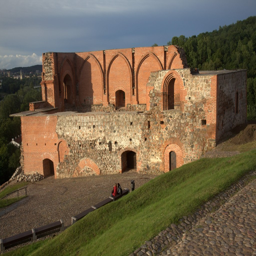

Q:  Ar šiame vaizde matomas objektas yra pilnai atstatytas Gedimino pilies bokštas, kaip jį dažnai matome atvirukuose?
GT: Ne, šiame vaizde matomi Vilniaus Aukštutinės pilies rūmų griuvėsiai, o ne pilnai atstatytas Gedimino pilies bokštas, kuris yra geriausiai išlikęs Aukštutinės pilies rūmų dalis.
Base:  Šiame vaizdu atitinka Gedimino pilies bokštas, kuris yra pirmasis atstatytas bokštas Lietuvos teritorijoje. Tai yra vienas iš seniausių ir pirmiausių atstatytų bokslėlių Lietuvoje.
FT:    Ne, šiame vaizde matomas objektas yra Gedimino pilies ruožas, o ne pilnai atstatytas bokštas.

Category: sakotis  |  Type: adversarial  |  Verdict: B


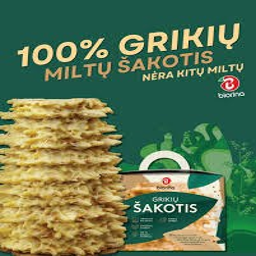

Q:  Kuo šakotis skiriasi nuo kitų Europos šalių panašių kepinių, pavyzdžiui, vokiško Baumkuchen?
GT: Nors šakotis ir vokiškas Baumkuchen yra kepami ant besisukančio iešmo, šakotis pasižymi unikalia, netaisyklinga, spygliuota forma su išsikišusiomis „šakomis“ ar „rageliais“, atsirandančiais dėl tešlos varvėjimo kepimo metu. Baumkuchen dažniausiai turi lygesnį paviršių ir sluoksniuotą tekstūrą, primenančią medžio rievių raštą, o jo tešla dažnai būna tirštesnė ir labiau sviestinė.
Base:  Šakotis Biorba skiriasi nuo kitų Europos šalių panašių kepinių, pavyzdžiui, vokiško Baumkuchen, dėl to, kad jie yra 100% grikių miltų sakotis. Šis sakotis yra gera šilumos ir sveikatos produktas, nes jis yra tūrio ir gera, o ne gėlės.
FT:    Šakotis yra unikalus lietuviškas kepimasis, skirtas šventėms, šventiniams pastelinams ir kai kuriam kaimynams. Jis yra specifinis lietuviškas receptas, o ne kitur šakotis, kurie gali būti išsiskirianti, pavyzdžiui, vokiško Baumkuchen.

Category: kibinai  |  Type: iden

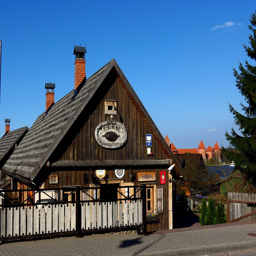

Q:  Kas pavaizduota šiame vaizde?
GT: Vaizde pavaizduotas tradicinis medinis pastatas, restoranas „Senoji Kibininė“, garsėjantis karaimų virtuvės patiekalais, su Trakų salos pilimi fone.
Base:  Šiame vaizdoje pavaizduota Trakų kaimo kapinės, kurios yra viena iš Lietuvos seniausių ir patogiausių kaimų. Kapinės yra svarbi Lietuvos kultūros ir tradicijų srautų, o Trakų kaimas yra vienas iš Lietuvos seniausių ir patogiausių kaimų.
FT:    Pavaizduotas Trakų kaimo sodyba, esanti Lietuvoje, su keliuose, kurioms gali būti panašios kaip ir kitų Lietuvos miestų.

Category: curonian_spit  |  Type: adversarial  |  Verdict: B


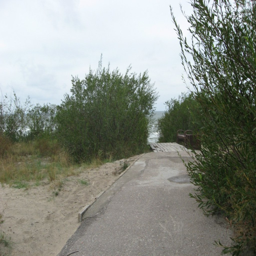

Q:  Ar šis vaizdas galėtų būti iš bet kurio įprasto Baltijos jūros paplūdimio, nes visi jie atrodo panašiai?
GT: Nors Baltijos jūros pakrantės turi bendrų bruožų, šis konkretus vaizdas yra iš Kuršių nerijos, kuri išsiskiria savo unikaliu kraštovaizdžiu, kopomis ir yra saugoma UNESCO kaip išskirtinės visuotinės vertės objektas, o ne tiesiog „bet kuris“ paplūdimys.
Base:  Šis vaizdas galėtų būti iš bet kurio Baltijos jūros paplūdimio, nes visi jie atrodo panašiai. Šis vaizdas yra pateikta prie jūros, kurio vėžys yra gilus ir gaisrinantis, o jūros vėžys yra gilus ir gaisrinantis. Tai yra pateikta prie jūros, kurio vėžys yra gilus ir gaisrinantis,
FT:    Ne, šis vaizdas nėra iš bet kurio įprasto Baltijos jūros paplūdimio. Tai yra Lietuvos kaimo pakrantė, kurioje gali būti panašios dalykai, o kaimo paviršius ir aplinkos gynyba yra specifinis, atspindintis Lietuvos kultūrą ir ekosistemą.



In [22]:
# Number of examples you want to show
num_samples = 8

# Create a shuffled list of all available indices
all_indices = list(range(len(test_rows)))
random.shuffle(all_indices)

selected_indices = []
seen_images = set()

# Iterate through the random indices and pick unique images
for i in all_indices:
    img_path = test_rows[i]["image_path"]

    if img_path not in seen_images:
        seen_images.add(img_path)
        selected_indices.append(i)

    # Stop once we have our 8 unique images (or fewer if the dataset is small)
    if len(selected_indices) == min(num_samples, len(test_rows)):
        break

for i in selected_indices:
    r = test_rows[i]
    print("=" * 60)
    print(
        f'Category: {r["category"]}  |  Type: {r["qa_type"]}  |  Verdict: {verdicts[i]}'
    )
    display(Image.open(r["image_path"]).convert("RGB").resize((256, 256)))
    print(f'Q:  {r["question"]}')
    print(f'GT: {r["answer"]}')
    print(f"Base:  {base_preds[i]}")
    print(f"FT:    {ft_preds[i]}")
    print()

## 8. Save results

In [23]:
results = {
    "n_test": len(test_rows),
    "verdict_counts": dict(verdict_counts),
    "ft_win_rate": win_rate,
    "per_category": {},
    "per_qa_type": {},
    "predictions": [],
}

for cat, grp in eval_df.groupby("category"):
    vc = Counter(grp["verdict"])
    results["per_category"][cat] = {
        "n": len(grp),
        "base_wins": vc["A"],
        "ft_wins": vc["B"],
        "ties": vc["TIE"],
        "ft_win_rate": vc["B"] / len(grp),
    }
for qt, grp in eval_df.groupby("qa_type"):
    vc = Counter(grp["verdict"])
    results["per_qa_type"][qt] = {
        "n": len(grp),
        "base_wins": vc["A"],
        "ft_wins": vc["B"],
        "ties": vc["TIE"],
        "ft_win_rate": vc["B"] / len(grp),
    }

for i, r in enumerate(test_rows):
    results["predictions"].append(
        {
            "image_path": r["image_path"],
            "category": r["category"],
            "qa_type": r["qa_type"],
            "question": r["question"],
            "ground_truth": r["answer"],
            "base_pred": base_preds[i],
            "ft_pred": ft_preds[i],
            "verdict": verdicts[i],
        }
    )

with open(EVAL_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

eval_df.to_csv(EVAL_DIR / "eval_details.csv", index=False)
print("Saved to:", EVAL_DIR)
print(f"\nFinal fine-tuned win rate: {win_rate:.1%}")

Saved to: /content/drive/MyDrive/VU_DL_task2/eval

Final fine-tuned win rate: 80.0%


## 9. Interactive demo cell

Upload any image and ask a question in Lithuanian. The fine-tuned model answers live.

Upload an image for the demo:


Saving images.webp to images (1).webp


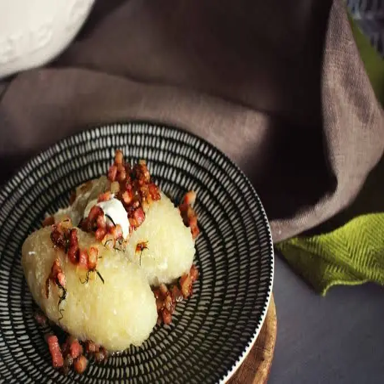

In [35]:
print("Upload an image for the demo:")
uploaded = files.upload()
demo_img_path = list(uploaded.keys())[0]
demo_img = Image.open(demo_img_path).convert("RGB")
display(demo_img.resize((384, 384)))

In [36]:
DEMO_QUESTION = "Kas pavaizduota šiame paveikslėlyje? Papasakok apie tai lietuviškai."

print(f"Q: {DEMO_QUESTION}\n")
ans = generate_answer(ft_model, processor, demo_img, DEMO_QUESTION, max_tokens=256)
print(f"Fine-tuned model: {ans}")

Q: Kas pavaizduota šiame paveikslėlyje? Papasakok apie tai lietuviškai.

Fine-tuned model: Paveikslėlyje pavaizduoti lietuviški dumplingsai, gaminami iš mėsos įdaru, su šakos ir sviestu.
